# Written text as operational data

Written text is one type of data

### Why people write?

 - To communicate: their thoughts, feelings, urgency, needs, information

### Why people communicate?

1. To express emotions
1. To share information
1. To enable or elicit an action
1. ...

### We will use written text for the purpose other than 
1. To experience emotion
1. To learn something the author intended us to learn
1. To do what the author intended us to do

### Instead, we will use written text to recognize who wrote it
 - By calculating and comparing word frequencies in written documents
 
See, for example, likely fictional story https://medium.com/@amuse/how-the-nsa-caught-satoshi-nakamoto-868affcef595

### Example 1. Dictionaries in python (associative arrays)

Plot the frequency distribution of words on a web page.

In [1]:
import requests, re
# re is a module for regular expressions: to detect various combinations of characters
import operator

# Start from a simple document
r = requests .get('http://eecs.utk.edu')

# What comes back includes headers and other HTTP stuff, get just the body of the response
t = r.text

# obtain words by splitting a string using as separator one or more (+) space/like characters (\s) 
wds = re.split('\s+',t)

# now populate a dictionary (wf)
wf = {}
for w in wds:
    if w in wf: wf [w] = wf [w] + 1
    else:  wf[w] = 1

# dictionaries can not be sorted, so lets get a sorted *list*        
wfs = sorted (wf .items(), key = operator .itemgetter (1), reverse=True)   

# lets just have no more than 15 words 
ml = min(len(wfs),15)
for i in range(1,ml,1):
    print (wfs[i][0]+"\t"+str(wfs[i][1]))  

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
C:\Users\owner\AppData\Local\Temp\ipykernel_43224\2163542720.py:12: SyntaxWarning: invalid escape sequence '\s'
  wds = re.split('\s+',t)


class="menu-item	63
menu-item-type-post_type	61
menu-item-object-page	61
<div	47
</div>	44
and	36
<a	29
-->	26
/>	26
of	25
<link	19
<!--	18
0	18
H.	17


### Example 2

Lots of markup in the output, lets remove it --- 

use BeautifulSoup and nltk modules and practice some regular expressions.

In [2]:
import requests, re, nltk
from bs4 import BeautifulSoup
from collections import Counter
import operator

# we may not care about the usage of stop words
stop_words = nltk.corpus.stopwords.words('english') + [
 'ut', '\'re','.', ',', '--', '\'s', '?', ')', '(', ':', '\'',
 '\"', '-', '}', '{', '&', '|', u'\u2014' ]

# We most likely would like to remove html markup
def cleanHtml (html):
    from bs4 import BeautifulSoup
    soup = BeautifulSoup(html, 'html.parser')
    return soup .get_text()

# We also want to remove special characters, quotes, etc. from each word
def cleanWord (w):
    # r in r'[.,"\']' tells to treat \ as a regular character 
    # but we need to escape ' with \'
    # any character between the brackets [] is to be removed 
    wn = re.sub('[,"\.\'&\|:@>*;/=]', "", w)
    # get rid of numbers
    return re.sub('^[0-9\.]*$', "", wn)
       
# define a function to get text/clean/calculate frequency
def get_wf (URL):
    # first get the web page
    r = requests .get(URL)
    
    # Now clean
    # remove html markup
    t = cleanHtml (r .text) .lower()
    
    # split string into an array of words using any sequence of spaces "\s+" 
    wds = re .split('\s+',t)
    
    # remove periods, commas, etc stuck to the edges of words
    for i in range(len(wds)):
        wds [i] = cleanWord (wds [i])
    
    # If satisfied with results, lets go to the next step: calculate frequencies
    # We can write a loop to create a dictionary, but 
    # there is a special function for everything in python
    # in particular for counting frequencies (like function table() in R)
    wf = Counter (wds)
    
    # Remove stop words from the dictionary wf
    for k in stop_words:
        wf. pop(k, None)
        
    #how many regular words in the document?
    tw = 0
    for w in wf:
       tw += wf[w] 
        
    
    # Get ordered list
    wfs = sorted (wf .items(), key = operator.itemgetter(1), reverse=True)
    ml = min(len(wfs),15)

    #Reverse the list because barh plots items from the bottom
    return (wfs [ 0:ml ] [::-1], tw)
        
# Now populate two lists    
(wf_ee, tw_ee) = get_wf('http://www.gutenberg.org/ebooks/1342.txt.utf-8')
(wf_bu, tw_bu) = get_wf('http://www.gutenberg.org/ebooks/76.txt.utf-8')

<>:22: SyntaxWarning: invalid escape sequence '\.'
<>:24: SyntaxWarning: invalid escape sequence '\.'
<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\.'
<>:24: SyntaxWarning: invalid escape sequence '\.'
<>:36: SyntaxWarning: invalid escape sequence '\s'
C:\Users\owner\AppData\Local\Temp\ipykernel_43224\1662585158.py:22: SyntaxWarning: invalid escape sequence '\.'
  wn = re.sub('[,"\.\'&\|:@>*;/=]', "", w)
C:\Users\owner\AppData\Local\Temp\ipykernel_43224\1662585158.py:24: SyntaxWarning: invalid escape sequence '\.'
  return re.sub('^[0-9\.]*$', "", wn)
C:\Users\owner\AppData\Local\Temp\ipykernel_43224\1662585158.py:36: SyntaxWarning: invalid escape sequence '\s'
  wds = re .split('\s+',t)
C:\Users\owner\AppData\Local\Temp\ipykernel_43224\1662585158.py:22: SyntaxWarning: invalid escape sequence '\.'
  wn = re.sub('[,"\.\'&\|:@>*;/=]', "", w)
C:\Users\owner\AppData\Local\Temp\ipykernel_43224\1662585158.py:24: SyntaxWarning: invalid esca

LookupError: 
**********************************************************************
  Resource 'stopwords' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('stopwords')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'corpora/stopwords'

  Searched in:
    - 'C:\\Users\\owner/nltk_data'
    - 'C:\\Users\\owner\\AppData\\Local\\Programs\\Python\\Python313\\nltk_data'
    - 'C:\\Users\\owner\\AppData\\Local\\Programs\\Python\\Python313\\share\\nltk_data'
    - 'C:\\Users\\owner\\AppData\\Local\\Programs\\Python\\Python313\\lib\\nltk_data'
    - 'C:\\Users\\owner\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [ ]:
#Plot the results: are there striking differences in language?
import numpy as np
import pylab
import matplotlib.pyplot as plt

%matplotlib inline
def plotTwoLists (wf_ee, wf_bu, title):
    f = plt.figure (figsize=(10, 6))
    # this is painfully tedious....
    f .suptitle (title, fontsize=20)
    ax = f.add_subplot(111)
    ax .spines ['top'] .set_color ('none')
    ax .spines ['bottom'] .set_color ('none')
    ax .spines ['left'] .set_color ('none')
    ax .spines ['right'] .set_color ('none')
    ax .tick_params (labelcolor='w', top='off', bottom='off', left='off', right='off', labelsize=20)

    # Create two subplots, this is the first one
    ax1 = f .add_subplot (121)
    plt .subplots_adjust (wspace=.5)

    pos = np .arange (len(wf_ee)+1) 
    ax1 .tick_params (axis='both', which='major', labelsize=14)
    pylab .yticks (pos, [ x [0] for x in wf_ee ])
    ax1 .barh (range(len(wf_ee)), [ x [1] for x in wf_ee ], align='center')

    ax2 = f .add_subplot (122)
    ax2 .tick_params (axis='both', which='major', labelsize=14)
    pos = np .arange (len(wf_bu)+1) 
    pylab .yticks (pos, [ x [0] for x in wf_bu ])
    ax2 .barh (range (len(wf_bu)), [ x [1] for x in wf_bu ], align='center')

plotTwoLists (wf_ee, wf_bu, 'Difference between Pride and Prejudice and Huck Finn')

In [3]:
#In case Project gutenberg is blocked you can download text to your laptop and copy to the docker container via scp
#Assuming the file name you copy is pg4680.txt here is how you change the script
# Please note the option errors='replace'
# without it python invariably runs into unicode errors
f = open ('pg4680.txt', 'r', encoding="ascii", errors='replace')
    
# What comes back includes headers and other HTTP stuff, get just the body of the response
t = f.read()

# obtain words by splitting a string using as separator one or more (+) space/like characters (\s) 
wds = re.split('\s+',t)

# now populate a dictionary (wf)
wf = {}
for w in wds:
    if w in wf: wf [w] = wf [w] + 1
    else:  wf [w] = 1

# dictionaries can not be sorted, so lets get a sorted *list*        
wfs = sorted (wf .items(), key = operator .itemgetter (1), reverse=True)   

# lets just have no more than 15 words 
ml = min(len(wfs),15)
for i in range(1,ml,1):
    print (wfs[i][0]+"\t"+str(wfs[i][1]))  

and	2836
of	2676
to	2646
a	2217
in	1422
his	1205
he	928
that	920
was	823
for	798
with	797
as	672
I	505
you	497


<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\owner\AppData\Local\Temp\ipykernel_43224\2156801871.py:11: SyntaxWarning: invalid escape sequence '\s'
  wds = re.split('\s+',t)


# Assignment 1

1. Compare word frequencies between two works of a single author.
1. Compare word frequencies between works of two authors.
1. Are there some words preferred by one author but used less frequently by another author?

Extra credit

1. The frequency of a specific word, e.g., "would" should follow a binomial distribution (each regular word in a document is a trial and with probability p that word is "would". The estimate for p is N("would")/N(regular word)). Do these binomial distributions for your chosen word differ significantly between books of the same author or between authors? 

Project Gutenberg is a good source of for fiction and non-fiction.

E.g below are two most popular books from Project Gutenberg:
- Pride and Prejudice at http://www.gutenberg.org/ebooks/1342.txt.utf-8
- Adventures of Huckleberry Finn at http://www.gutenberg.org/ebooks/76.txt.utf-8

# jmill291 - Mini Project 1

## Research Question

How do word choices differ between works by the same author, and how do they differ between authors?

For the same-author comparison, I will compare two novels by **Jane Austen**:

- *Pride and Prejudice*
- *Sense and Sensibility*

For the second same-author comparison, I will compare two novels by **Mark Twain**:

- *Adventures of Huckleberry Finn*
- *The Adventures of Tom Sawyer*

I will then compare the combined word usage of Austen with the combined word usage of Twain.

## Goal

The goal is to determine whether an author's word-frequency patterns remain similar across different books and whether some words are much more common for one author than another.

## Data Source

The texts come from **Project Gutenberg**, which provides public-domain books in plain-text form.

## Approach

1. Download the four books.
2. Remove Project Gutenberg headers and footers.
3. Convert all text to lowercase.
4. Extract words and remove common English stop words.
5. Count the frequency of each remaining word.
6. Normalize word counts so books of different lengths can be compared fairly.
7. Compare the most common words within each author.
8. Compare Jane Austen's combined vocabulary with Mark Twain's combined vocabulary.
9. Identify words that are especially preferred by one author.

In [13]:
import re
import requests
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter



# A small word list keeps the notebook from depending on NLTK
STOP_WORDS = {
    'a','an','the','and','or','but','if','while','of','at','by','for','with','about',
    'against','between','into','through','during','before','after','above','below','to',
    'from','up','down','in','out','on','off','over','under','again','further','then',
    'once','here','there','when','where','why','how','all','any','both','each','few',
    'more','most','other','some','such','no','nor','not','only','own','same','so','than',
    'too','very','can','will','just','should','now','i','me','my','myself','we','our',
    'ours','ourselves','you','your','yours','yourself','yourselves','he','him','his',
    'himself','she','her','hers','herself','it','its','itself','they','them','their',
    'theirs','themselves','what','which','who','whom','this','that','these','those',
    'am','is','are','was','were','be','been','being','have','has','had','having','do',
    'does','did','doing','would','could','ought','im','ive','dont','didnt','cant',
    'wont','youre','hes','shes','theyre','thats','theres'
}


BOOKS = {
    "Pride and Prejudice": {
        "author": "Jane Austen",
        "url": "https://www.gutenberg.org/cache/epub/1342/pg1342.txt"
    },
    "Sense and Sensibility": {
        "author": "Jane Austen",
        "url": "https://www.gutenberg.org/cache/epub/161/pg161.txt"
    },
    "Huckleberry Finn": {
        "author": "Mark Twain",
        "url": "https://www.gutenberg.org/cache/epub/76/pg76.txt"
    },
    "Tom Sawyer": {
        "author": "Mark Twain",
        "url": "https://www.gutenberg.org/cache/epub/74/pg74.txt"
    }
}

def download_text(url):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    return response.text

def remove_gutenberg_header_footer(text):
    #Gutenberg books normally place the book between START and END markers.
    start = re.search(r"\*\*\*\s*START OF THE PROJECT GUTENBERG EBOOK.*?\*\*\*", text,
                      flags=re.IGNORECASE | re.DOTALL)
    end = re.search(r"\*\*\*\s*END OF THE PROJECT GUTENBERG EBOOK.*?\*\*\*", text,
                    flags=re.IGNORECASE | re.DOTALL)
    if start:
        text = text[start.end():]
    if end:
        text = text[:end.start()]
    return text

def tokenize(text):
    # Keep alphabetic words and apostrophes, then normalize to lowercase.
    words = re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?", text.lower())
    cleaned = []
    for word in words:
        word = word.replace("’", "'")
        if word not in STOP_WORDS and len(word) > 1:
            cleaned.append(word)
    return cleaned


def get_counts(text):
    words = tokenize(remove_gutenberg_header_footer(text))
    return Counter(words), len(words)

texts = {}
counts = {}
totals = {}

for title, info in BOOKS.items():
    text = download_text(info["url"])
    texts[title] = text
    counts[title], totals[title] = get_counts(text)

print("Books downloaded and processed:")
for title in BOOKS:
    print(f"{title}: {totals[title]:,} non-stop words")


Books downloaded and processed:
Pride and Prejudice: 58,413 non-stop words
Sense and Sensibility: 54,427 non-stop words
Huckleberry Finn: 52,930 non-stop words
Tom Sawyer: 36,074 non-stop words


## 1. Compare word frequencies between two works of a single author

First, I compare *Pride and Prejudice* with *Sense and Sensibility*. Because the books have different lengths, I use **frequency per 10,000 words** instead of raw counts.

In [5]:
def normalized_top_words(counter, total, n=15):
    rows = []
    for word, count in counter.most_common(n):
        rows.append((word, count, count / total * 10000))
    return pd.DataFrame(rows, columns=["Word", "Count", "Per 10,000 Words"])

austen_pp = normalized_top_words(counts["Pride and Prejudice"], totals["Pride and Prejudice"])
austen_ss = normalized_top_words(counts["Sense and Sensibility"], totals["Sense and Sensibility"])

print("Pride and Prejudice")
display(austen_pp)

print("\nSense and Sensibility")
display(austen_ss)

Pride and Prejudice


,Word,Count,"Per 10,000 Words"
0,as,1229,210.398370
1,mr,808,138.325373
2,elizabeth,645,110.420626
3,darcy,432,73.956140
4,said,406,69.505076
5,mrs,354,60.602948
6,bennet,339,58.035026
7,much,337,57.692637
8,miss,315,53.926352
9,must,315,53.926352



Sense and Sensibility


,Word,Count,"Per 10,000 Words"
0,as,1222,224.520918
1,elinor,685,125.856652
2,marianne,566,103.992504
3,mrs,530,97.378140
4,said,397,72.941738
5,every,376,69.083359
6,one,333,61.182869
7,much,290,53.282378
8,must,283,51.996252
9,sister,282,51.812520


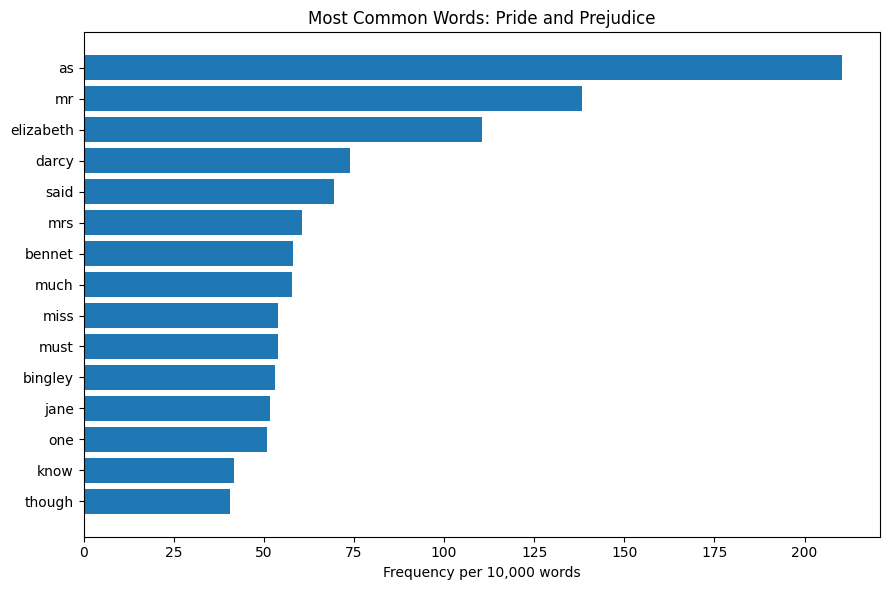

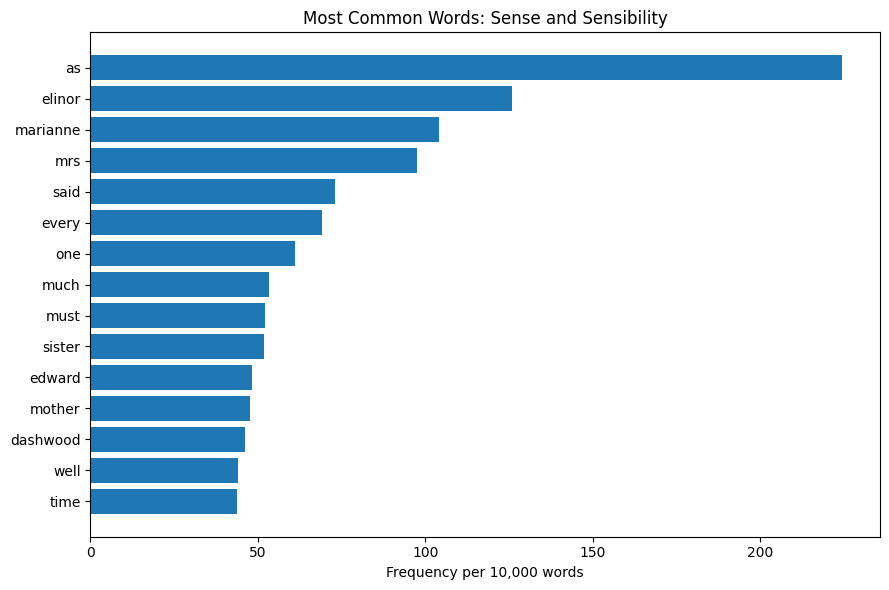

In [6]:
def plot_top_words(title, n=15):
    df = normalized_top_words(counts[title], totals[title], n).sort_values("Per 10,000 Words")
    plt.figure(figsize=(9,6))
    plt.barh(df["Word"], df["Per 10,000 Words"])
    plt.xlabel("Frequency per 10,000 words")
    plt.title(f"Most Common Words: {title}")
    plt.tight_layout()
    plt.show()

plot_top_words("Pride and Prejudice")
plot_top_words("Sense and Sensibility")

### Jane Austen comparison

The two Austen novels can now be compared using the tables and graphs above. Repeated character names will naturally differ because the books have different casts, but recurring descriptive and conversational vocabulary can reveal similarities in Austen's writing style.

Mark Twain same-author comparison

Huckleberry Finn


,Word,Count,"Per 10,000 Words"
0,says,638,120.536558
1,got,624,117.891555
2,as,544,102.777253
3,said,492,92.952957
4,see,477,90.119025
5,well,417,78.783299
6,come,399,75.382581
7,one,397,75.004723
8,jim,390,73.682222
9,didn,361,68.203287



Tom Sawyer


,Word,Count,"Per 10,000 Words"
0,tom,820,227.310528
1,as,397,110.051561
2,said,356,98.686034
3,huck,258,71.519654
4,ll,232,64.312247
5,don,224,62.094583
6,one,192,53.223929
7,time,191,52.946721
8,got,177,49.065809
9,well,175,48.511393


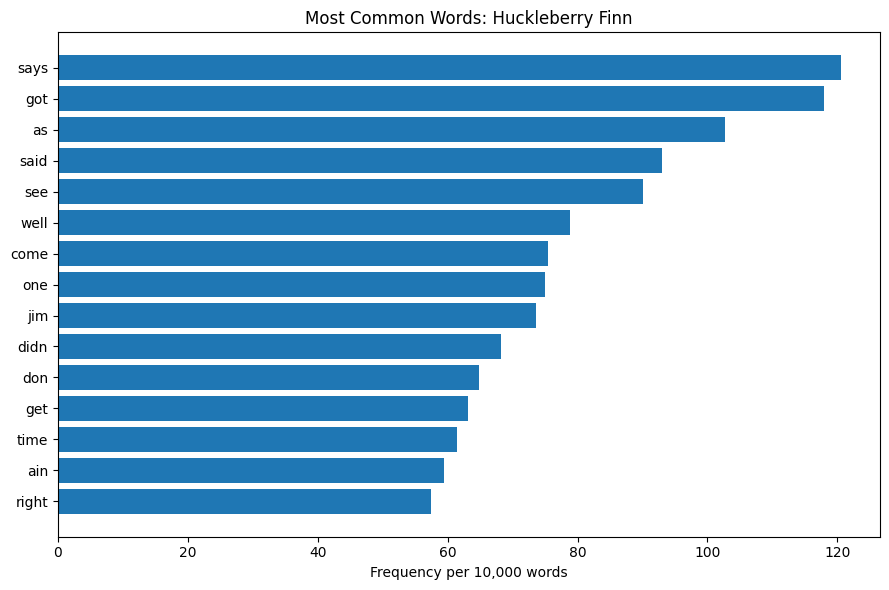

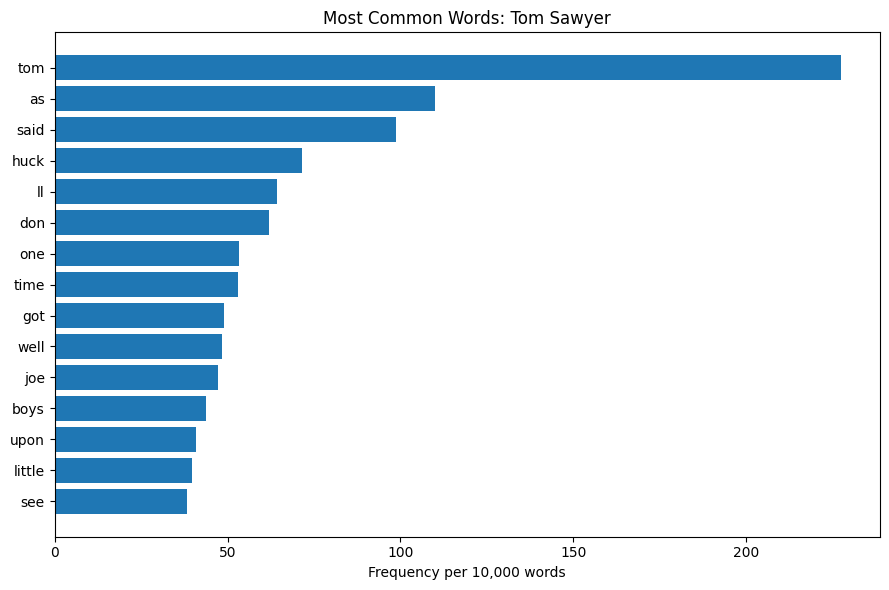

In [7]:
print("Mark Twain same-author comparison")

twain_hf = normalized_top_words(counts["Huckleberry Finn"], totals["Huckleberry Finn"])
twain_ts = normalized_top_words(counts["Tom Sawyer"], totals["Tom Sawyer"])

print("\nHuckleberry Finn")
display(twain_hf)

print("\nTom Sawyer")
display(twain_ts)

plot_top_words("Huckleberry Finn")
plot_top_words("Tom Sawyer")

### Mark Twain comparison

The Twain comparison provides a second example of how one author's vocabulary changes between books. Character names and plot-specific terms are expected to vary, while repeated informal or conversational words may be more representative of the author's style.

## 2. Compare word frequencies between works of two authors

For the author-level comparison, I combine the two Austen books into one word-frequency dictionary and the two Twain books into another. Combining two books reduces the chance that one plot or one set of character names dominates the comparison.

In [12]:
def combine_counters(*items):
    combined = Counter()
    for c in items:
        combined.update(c)
    return combined

austen_counts = combine_counters(
    counts["Pride and Prejudice"],
    counts["Sense and Sensibility"]
)
twain_counts = combine_counters(
    counts["Huckleberry Finn"],
    counts["Tom Sawyer"]
)


austen_total = totals["Pride and Prejudice"] + totals["Sense and Sensibility"]
twain_total = totals["Huckleberry Finn"] + totals["Tom Sawyer"]


austen_top = normalized_top_words(austen_counts, austen_total, 20)
twain_top = normalized_top_words(twain_counts, twain_total, 20)


print("Jane Austen - combined top words")
display(austen_top)


print("\nMark Twain - combined top words")
display(twain_top)

Jane Austen - combined top words


,Word,Count,"Per 10,000 Words"
0,as,2451,217.210209
1,mr,986,87.380362
2,mrs,884,78.341014
3,said,803,71.162708
4,elinor,685,60.705424
5,elizabeth,645,57.160581
6,one,630,55.831266
7,much,627,55.565402
8,must,598,52.995392
9,marianne,566,50.159518



Mark Twain - combined top words


,Word,Count,"Per 10,000 Words"
0,tom,1063,119.432834
1,as,941,105.725585
2,said,848,95.276617
3,got,801,89.995955
4,says,654,73.479844
5,see,615,69.098018
6,well,592,66.513865
7,one,589,66.176801
8,don,567,63.705002
9,come,528,59.323176


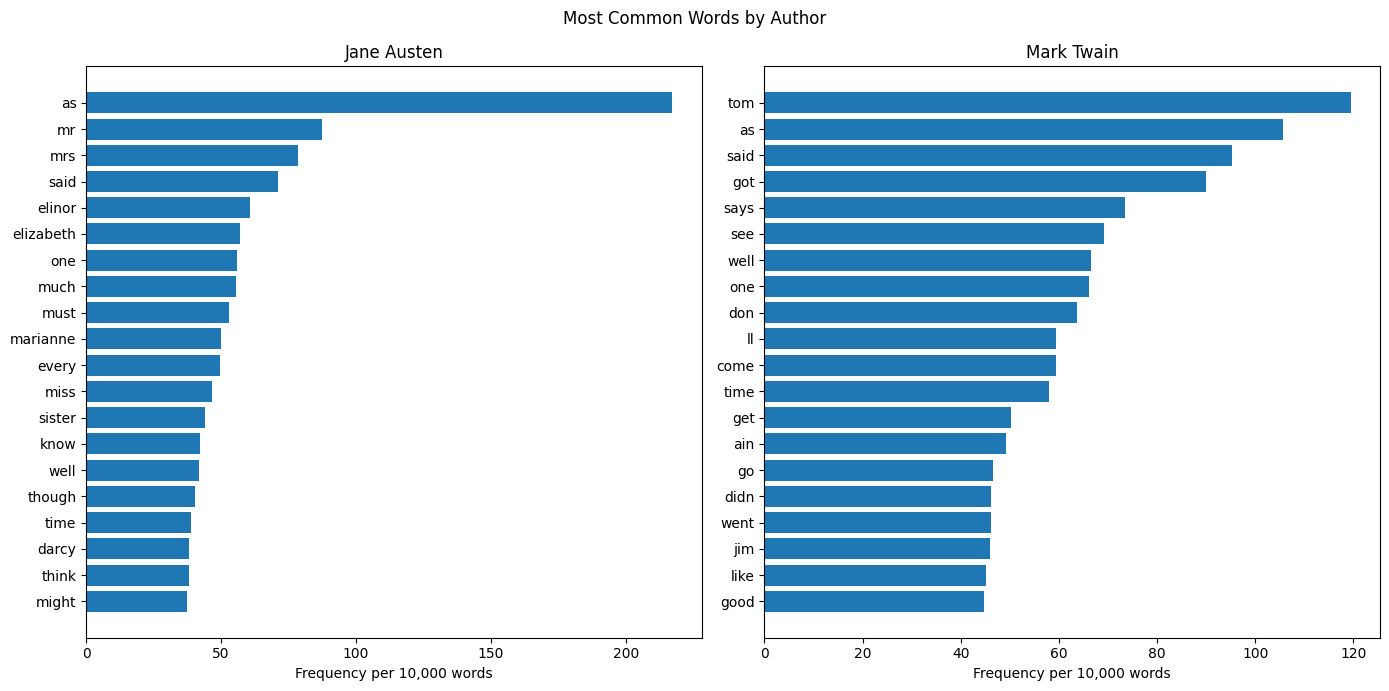

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

a = austen_top.sort_values("Per 10,000 Words")
t = twain_top.sort_values("Per 10,000 Words")

axes[0].barh(a["Word"], a["Per 10,000 Words"])
axes[0].set_title("Jane Austen")
axes[0].set_xlabel("Frequency per 10,000 words")

axes[1].barh(t["Word"], t["Per 10,000 Words"])
axes[1].set_title("Mark Twain")
axes[1].set_xlabel("Frequency per 10,000 words")

plt.suptitle("Most Common Words by Author")
plt.tight_layout()
plt.show()


## 3. Are some words preferred by one author?

A word is more useful for distinguishing authors when it appears often enough to matter and has a noticeably different **normalized frequency**. The code below considers words that appear at least 20 times across the selected books and calculates how much more frequently each author uses them.

In [10]:
def distinctive_words(counter_a, total_a, counter_b, total_b, min_combined_count=20, n=20):
    vocabulary = set(counter_a) | set(counter_b)
    rows = []

    for word in vocabulary:
        ca = counter_a[word]
        cb = counter_b[word]

        if ca + cb < min_combined_count:
            continue

        fa = ca / total_a * 10000
        fb = cb / total_b * 10000

        # Difference in normalized frequency.
        rows.append((word, ca, cb, fa, fb, fa - fb))

    df = pd.DataFrame(
        rows,
        columns=[
            "Word", "Austen Count", "Twain Count",
            "Austen per 10k", "Twain per 10k",
            "Austen minus Twain"
        ]
    )

    most_austen = df.sort_values("Austen minus Twain", ascending=False).head(n)
    most_twain = df.sort_values("Austen minus Twain", ascending=True).head(n)

    return most_austen, most_twain

most_austen, most_twain = distinctive_words(
    austen_counts, austen_total,
    twain_counts, twain_total
)

print("Words relatively more common in Jane Austen")
display(most_austen)

print("\nWords relatively more common in Mark Twain")
display(most_twain)



Words relatively more common in Jane Austen


,Word,Austen Count,Twain Count,Austen per 10k,Twain per 10k,Austen minus Twain
723,as,2451,941,217.210209,105.725585,111.484624
479,mr,986,49,87.380362,5.505371,81.874991
47,mrs,884,33,78.341014,3.707699,74.633315
1263,elinor,685,0,60.705424,0.000000,60.705424
204,elizabeth,645,0,57.160581,0.000000,57.160581
1415,marianne,566,0,50.159518,0.000000,50.159518
1522,sister,499,17,44.221907,1.910027,42.311881
1685,must,598,106,52.995392,11.909577,41.085815
871,darcy,432,0,38.284296,0.000000,38.284296
1629,much,627,163,55.565402,18.313784,37.251619



Words relatively more common in Mark Twain


,Word,Austen Count,Twain Count,Austen per 10k,Twain per 10k,Austen minus Twain
1345,tom,0,1063,0.000000,119.432834,-119.432834
183,got,52,801,4.608295,89.995955,-85.387660
824,says,28,654,2.481390,73.479844,-70.998454
522,don,31,567,2.747253,63.705002,-60.957749
221,ll,4,528,0.354484,59.323176,-58.968692
707,ain,0,438,0.000000,49.211271,-49.211271
643,didn,0,411,0.000000,46.177700,-46.177700
1450,jim,0,409,0.000000,45.952991,-45.952991
626,get,85,447,7.532790,50.222462,-42.689672
1402,come,200,528,17.724211,59.323176,-41.598965


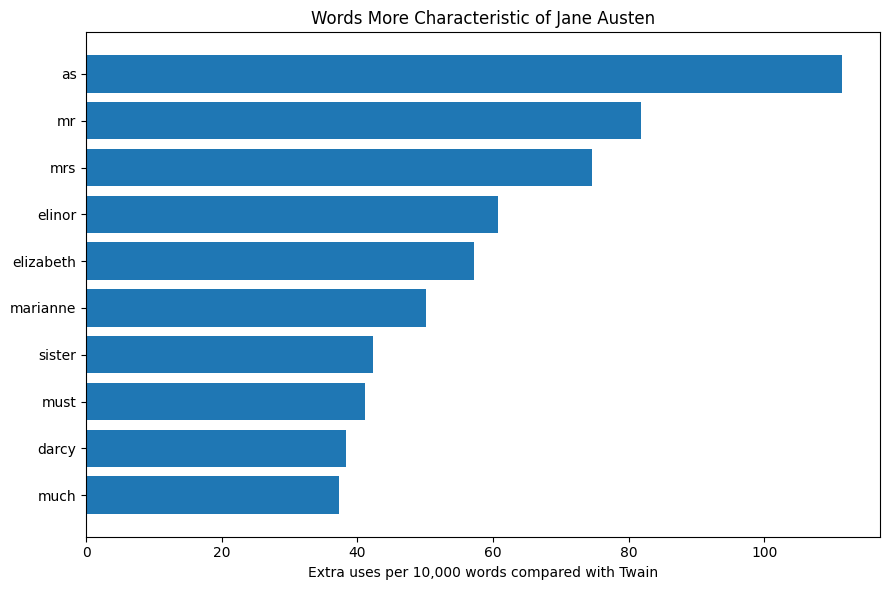

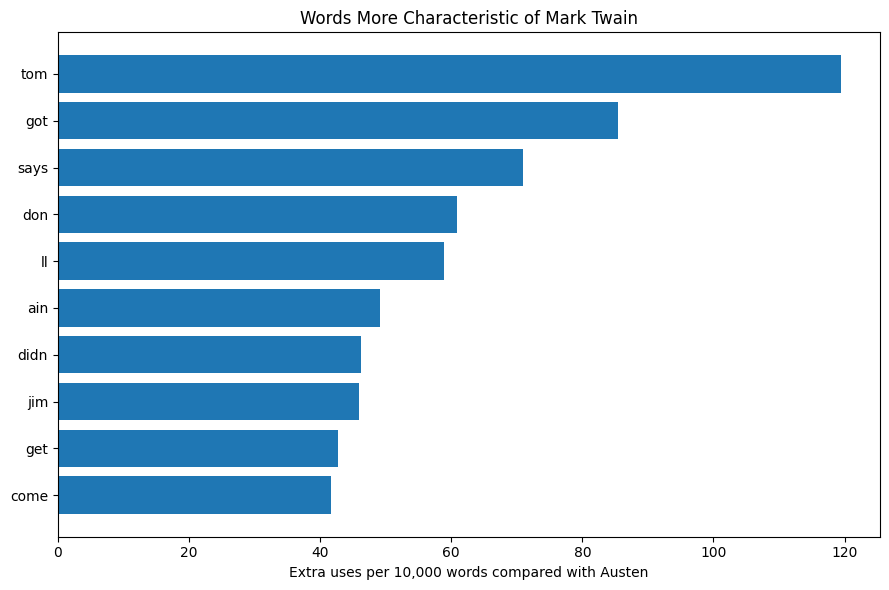

In [11]:
# Visualize the ten strongest differences in each direction.
a_plot = most_austen.head(10).sort_values("Austen minus Twain")
t_plot = most_twain.head(10).copy()
t_plot["Twain advantage"] = -t_plot["Austen minus Twain"]
t_plot = t_plot.sort_values("Twain advantage")

plt.figure(figsize=(9,6))
plt.barh(a_plot["Word"], a_plot["Austen minus Twain"])
plt.xlabel("Extra uses per 10,000 words compared with Twain")
plt.title("Words More Characteristic of Jane Austen")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,6))
plt.barh(t_plot["Word"], t_plot["Twain advantage"])
plt.xlabel("Extra uses per 10,000 words compared with Austen")
plt.title("Words More Characteristic of Mark Twain")
plt.tight_layout()
plt.show()

## Results

The analysis compares word frequencies in two ways. First, books by the same author are compared to see whether higher frequency vocabulary remains similar across different works. Second, the two Austen books and the two Twain books are combined to create a broader author comparison.
The most useful result is the distinctive word table. It shows the words with normalized frequencies differ the most between the two authors. Words with a large positive Austen minus Twain value occur much more often in Austen's selected books, while large negative values identify words used more often in Twain's selected books. This supports the idea that word frequency patterns can provide clues about authorship. At the same time, some differences are caused by each book's subject, setting, characters, and dialogue, so a single word should not be treated as proof of authorship.

## Problems Encountered

One issue is that raw word counts are misleading when books have different lengths. I handled this by converting the counts to frequency per 10,000 words. Another issue is that common English words such as "the", "and", and "of" dominate a basic frequency list but are not very informative. I removed common stop words before making the comparisons. Project Gutenberg files also contain headers, licensing text, and other material that was not written as part of the original novel. I removed the text outside the Project Gutenberg start and end markers when those markers were available. Finally, character names and story-specific vocabulary can appear as strong differences even though they may reflect the plot rather than the author's general writing style. Combining two books per author helps reduce this problem, but it does not remove it completely

## New Ideas

This project could be expanded by using more books from each author. A larger sample would make it easier to separate an author's writing habits from the topic of a specific book. Another improvement would be to examine two word and three word phrases instead of only single words. Phrases may capture writing style better than individual vocabulary items. A future analysis could also compare punctuation, sentence length, average word length, or function-word frequencies. Those features may be less dependent on a book's plot and could provide stronger evidence for author identification

## Conclusion

The project shows how operational traces in written text can be used for authorship analysis. Word-frequency patterns can be compared both within an author's works and across authors. Normalizing frequencies, removing common stop words, and looking for words with large frequency differences makes the comparison more meaningful. The results should not be interpreted as proving that one word identifies an author. Instead, many small patterns taken together provide evidence of differences in writing style. Using more books and additional text features would make the analysis stronger.